# Data learning curve — CNN-max & CNN-concat (curated peaks)

How does **test** peak-MAE improve as the **training set grows**? We hold out a **fixed 15% test set**
(seed 0) from the curated 758-sample dataset (**85/15** train/test), then train each model on increasing
fractions of the remaining **85% training pool** and evaluate on that same fixed test set.

- Architectures: **cnn-max** and **cnn-concat** (CNN over ESM-2 embeddings).
- **80 epochs** per fit (fixed, no val/early-stopping — we report test MAE after 80 epochs).
- Training-data fractions: **10% / 20% / 50% / 80% / 100%** of the 85% pool.
- Each train-size point is averaged over **3 random subset draws** (seeds 0–2) → mean ± std error bands.
- Targets standardized on each train subset; loss = standardized-peak MSE (Adam 1e-3, wd 1e-4, dropout 0.2).

## 0. Setup — curated data, embeddings, fixed test split

In [8]:
import csv, os, numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
def C(k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888"}.get(k,"#333")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
TD="training_data"; CUR=f"{TD}/curated"
rows=list(csv.DictReader(open(f"{CUR}/peak_assignments.csv"))); N=len(rows)
peaks=np.load(f"{CUR}/peaks.npy").astype(np.float32)
keep=np.load(f"{CUR}/keep_index.npy")
H=np.load(f"{TD}/esm_residue_fp16.npy")[keep]; Ls=np.load(f"{TD}/esm_residue_len.npy")[keep]
Lmax=int(Ls.max()); H=H[:,:Lmax]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
Pk=torch.tensor(peaks,device=dev)

# fixed held-out test set = 15% (seed 0); the rest (85%) is the training pool
perm=np.random.default_rng(0).permutation(N); n_te=int(round(0.15*N))
TEST=perm[:n_te]; POOL=perm[n_te:]
print(f"curated N={N} | fixed 15% test={len(TEST)} | 85% training pool={len(POOL)}")

def batches(idx,bs=32,shuffle=False,rng=None):
    idx=np.array(idx)
    if shuffle: rng.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]; yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
def test_mae(net,idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); T=peaks[idx]
    return 0.5*(np.abs(P[:,0]-T[:,0]).mean()+np.abs(P[:,1]-T[:,1]).mean())
def train_eval(pool, tr_idx, te_idx, seed, save_path=None):
    torch.manual_seed(seed); rng=np.random.default_rng(100+seed)
    mean=peaks[tr_idx].mean(0); std=peaks[tr_idx].std(0)+1e-6; sd=torch.tensor(std,device=dev)
    spec=dict(arch="cnn",pool=pool,conv_ch=128,k=5,hidden=256,nl=2)
    net=pm.wrap(pm.build_base(spec,dev,drop=0.2),mean,std,dev)
    opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=1e-4)
    for ep in range(80):
        net.train()
        for Hb,mk,b in batches(tr_idx,shuffle=True,rng=rng):
            opt.zero_grad(); (((net(Hb,mk)-Pk[torch.as_tensor(b,device=dev)])/sd)**2).mean().backward(); opt.step()
    if save_path is not None:                                    # cache the trained base net (+ scaler stats)
        pm.save_model(save_path, net.base, dict(spec, drop=0.2, mean=mean, std=std, n_train=len(tr_idx), seed=seed))
    return test_mae(net,te_idx), test_mae(net,tr_idx)

curated N=758 | fixed 15% test=114 | 85% training pool=644


## 1. Sweep training-set size (3 subset draws per point)

In [9]:
import json
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; POOLS=["max","concat"]
LC_CACHE="trained_models/data_learning_curve_sweep.json"         # test/train MAE vs train-size sweep (85/15, 80ep, 3 draws)
LC_MODEL_DIR="trained_models/lc_models"; os.makedirs(LC_MODEL_DIR,exist_ok=True)  # per-fit trained checkpoints
def lc_model_path(pool,f,sd): return f"{LC_MODEL_DIR}/cnn-{pool}_p{int(round(f*100))}_s{sd}.pt"
if os.path.exists(LC_CACHE):
    res=json.load(open(LC_CACHE))
    print(f"loaded learning-curve sweep cache: {LC_CACHE}")
    for pool in POOLS:
        r=res[pool]
        for i,f in enumerate(r["frac"]):
            print(f"  cnn-{pool:6} {int(f*100):3d}% pool | n_train={r['n'][i]:4d} | test MAE {r['te_mean'][i]:5.2f} ± {r['te_std'][i]:4.2f} nm | train MAE {r['tr_mean'][i]:5.2f}")
else:
    res={p:{"n":[],"frac":[],"te_mean":[],"te_std":[],"tr_mean":[]} for p in POOLS}
    for pool in POOLS:
        print(f"--- cnn-{pool} ---")
        for f in FRACS:
            n=int(round(f*len(POOL)))
            te,tr=[],[]
            for sd in SEEDS:
                sub=np.random.default_rng(sd).choice(POOL, n, replace=False)
                t_te,t_tr=train_eval(pool, sub, TEST, sd, save_path=lc_model_path(pool,f,sd)); te.append(t_te); tr.append(t_tr)
            r=res[pool]; r["n"].append(n); r["frac"].append(f)
            r["te_mean"].append(float(np.mean(te))); r["te_std"].append(float(np.std(te))); r["tr_mean"].append(float(np.mean(tr)))
            print(f"  {int(f*100):3d}% pool | n_train={n:4d} | test MAE {np.mean(te):5.2f} ± {np.std(te):4.2f} nm | train MAE {np.mean(tr):5.2f}")
    json.dump(res, open(LC_CACHE,"w"), indent=2)
    print(f"saved learning-curve sweep cache: {LC_CACHE}  ({sum(len(FRACS)*len(SEEDS) for _ in POOLS)} model checkpoints -> {LC_MODEL_DIR}/)")

loaded learning-curve sweep cache: trained_models/data_learning_curve_sweep.json
  cnn-max     10% pool | n_train=  64 | test MAE 25.99 ± 1.14 nm | train MAE  3.34
  cnn-max     20% pool | n_train= 129 | test MAE 24.21 ± 2.20 nm | train MAE 12.35
  cnn-max     50% pool | n_train= 322 | test MAE 18.27 ± 0.91 nm | train MAE  4.95
  cnn-max     80% pool | n_train= 515 | test MAE 15.68 ± 0.22 nm | train MAE  4.72
  cnn-max    100% pool | n_train= 644 | test MAE 13.68 ± 0.91 nm | train MAE  4.58
  cnn-concat  10% pool | n_train=  64 | test MAE 25.28 ± 2.24 nm | train MAE  4.20
  cnn-concat  20% pool | n_train= 129 | test MAE 27.40 ± 5.25 nm | train MAE 15.99
  cnn-concat  50% pool | n_train= 322 | test MAE 18.71 ± 0.85 nm | train MAE  6.85
  cnn-concat  80% pool | n_train= 515 | test MAE 14.95 ± 1.21 nm | train MAE  4.62
  cnn-concat 100% pool | n_train= 644 | test MAE 14.14 ± 0.62 nm | train MAE  5.29


## 2. Learning curve

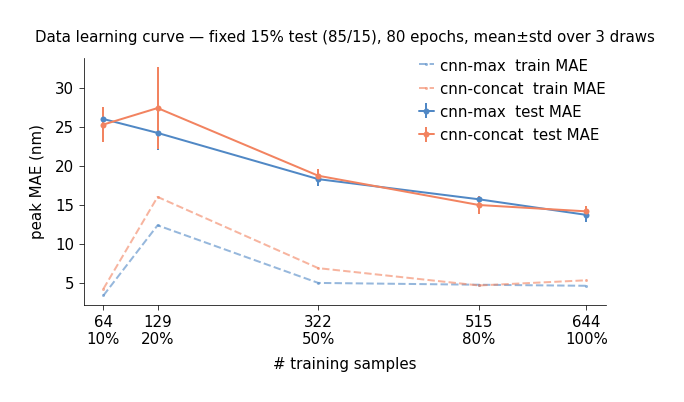

cnn-max: test MAE 26.0 nm @ 64 (10%) -> 13.7 nm @ 644 (100%)
cnn-concat: test MAE 25.3 nm @ 64 (10%) -> 14.1 nm @ 644 (100%)


In [24]:
fig,ax=plt.subplots(figsize=(8.5,5.2))
col={"max":C("aegean"),"concat":C("amber")}
for pool in POOLS:
    r=res[pool]; n=np.array(r["n"])
    ax.errorbar(n,r["te_mean"],yerr=r["te_std"],marker="o",capsize=3,color=col[pool],label=f"cnn-{pool}  test MAE")
    ax.plot(n,r["tr_mean"],ls="--",marker=".",color=col[pool],alpha=0.6,label=f"cnn-{pool}  train MAE")
ax.set_xlabel("# training samples"); ax.set_ylabel("peak MAE (nm)")
ax.set_title("Data learning curve — fixed 15% test (85/15), 80 epochs, mean±std over 3 draws")
ax.legend(fontsize=15)
ax.set_xticks(res["max"]["n"])
ax.set_xticklabels([f'{n}\n{int(f*100)}%' for n,f in zip(res["max"]["n"],res["max"]["frac"])])
plt.tight_layout(); fig.savefig("trained_models/data_learning_curve_85_15.png",dpi=130,bbox_inches="tight"); plt.show()
for pool in POOLS:
    r=res[pool]; print(f"cnn-{pool}: test MAE {r['te_mean'][0]:.1f} nm @ {r['n'][0]} (10%) -> {r['te_mean'][-1]:.1f} nm @ {r['n'][-1]} (100%)")

## 3. Ruggedness — does the peak jump between near-identical sequences?

Independent of any model: among FP pairs that are sequence-similar (4-mer-cosine prefilter, then exact alignment
identity), how much does the peak `0.5(|Δex|+|Δem|)` diverge as a function of identity? A **smooth** map drives
Δpeak→0 as identity→100%; a **rugged** one keeps a fat upper tail of large Δpeak even among near-twins. The
**median at high identity** is the intrinsic floor (best any model could do); the **upper tail** is the cliff
signal that caps a smoothly-interpolating model and inflates the test-error mean.

loaded ground-truth similarity–Δpeak cache: trained_models/similarity_deltapeak_truth.npz (34718 aligned pairs)
FLOOR  median Δpeak at identity>=0.98: 7.5 nm (n=1368)
RUGGED identity>=0.90 (n=20314): %Δ>20nm=58%  p95=103nm  max=218nm
identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm
  [0.70,0.85)    650    31.5   80.5  211.0    64%
  [0.85,0.90)  13097    31.5   75.0  217.5    64%
  [0.90,0.95)  12030    36.0   88.5  217.5    64%
  [0.95,0.98)   6916    23.5   71.2  201.5    54%
  [0.98,1.00)   1368     7.5   53.0  198.0    29%

top cliffs (id>=0.90, Δ>=30 nm; 10124 total):
  id 0.93  Δ   218  mNeptune684       (604,684) vs mTagBFP2          (399,454)
  id 0.93  Δ   216  mNeptune681       (604,681) vs mTagBFP2          (399,454)
  id 0.91  Δ   214  mNeptune684       (604,684) vs TagBFP            (402,457)
  id 0.91  Δ   213  mNeptune681       (604,681) vs TagBFP            (402,457)
  id 0.92  Δ   212  mCarmine          (603,675) vs mTagBFP2          (399,454)
  id 0.91  Δ   210  mTag

/var/folders/f4/yby3h8gx3h9btcfh8c1ff7v40000gn/T/ipykernel_18925/2668706665.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].set_title("Peak divergence vs identity"); ax[0].legend(fontsize=8)


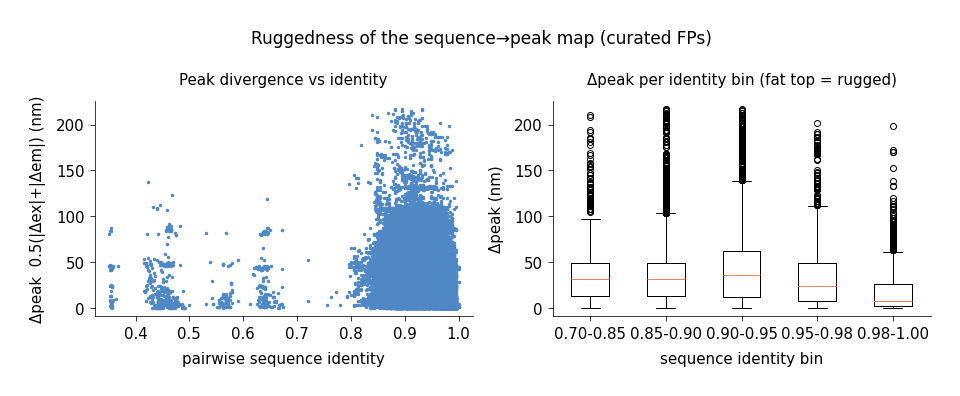

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
import biotite.sequence as bseq, biotite.sequence.align as balign
seqsR=[r["seq"] for r in rows]; namesR=[r["name"] for r in rows]
KMER_MIN=0.6                                                     # only align reasonably-similar pairs
GT_CACHE="trained_models/similarity_deltapeak_truth.npz"         # ground-truth identity vs Δpeak (aligned pairs)
if os.path.exists(GT_CACHE):
    _z=np.load(GT_CACHE); Ai,Bi,pid,dpk,kmer=_z["Ai"],_z["Bi"],_z["pid"],_z["dpk"],_z["kmer"]
    print(f"loaded ground-truth similarity–Δpeak cache: {GT_CACHE} ({len(pid)} aligned pairs)")
else:
    Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqsR)
    Sk=cossim(Xk); np.fill_diagonal(Sk,0.0)
    iu=np.triu_indices(N,1); km=Sk[iu]; sel=np.where(km>=KMER_MIN)[0]
    Ai=iu[0][sel]; Bi=iu[1][sel]; kmer=km[sel]
    print(f"aligning {len(sel)} candidate pairs (4-mer cos >= {KMER_MIN}) ...")
    MAT=balign.SubstitutionMatrix.std_protein_matrix()
    def _ident(a,b):
        aln=balign.align_optimal(bseq.ProteinSequence(a),bseq.ProteinSequence(b),MAT,gap_penalty=(-10,-1))[0]
        return float(balign.get_sequence_identity(aln))
    pid=np.array([_ident(seqsR[a],seqsR[b]) for a,b in zip(Ai,Bi)])
    dpk=0.5*(np.abs(peaks[Ai,0]-peaks[Bi,0])+np.abs(peaks[Ai,1]-peaks[Bi,1]))
    np.savez(GT_CACHE, Ai=Ai, Bi=Bi, pid=pid, dpk=dpk, kmer=kmer)
    print(f"saved ground-truth similarity–Δpeak cache: {GT_CACHE}")

floor=np.median(dpk[pid>=0.98]); rug=pid>=0.90
print(f"FLOOR  median Δpeak at identity>=0.98: {floor:.1f} nm (n={(pid>=0.98).sum()})")
print(f"RUGGED identity>=0.90 (n={rug.sum()}): %Δ>20nm={100*np.mean(dpk[rug]>20):.0f}%  p95={np.percentile(dpk[rug],95):.0f}nm  max={dpk[rug].max():.0f}nm")
bins=[(0.70,0.85),(0.85,0.90),(0.90,0.95),(0.95,0.98),(0.98,1.001)]
print("identity bin     n   medianΔ  p90Δ   maxΔ  %>20nm")
for lo,hi in bins:
    x=dpk[(pid>=lo)&(pid<hi)]
    if len(x): print(f"  [{lo:.2f},{hi:.2f})  {len(x):5d}  {np.median(x):6.1f}  {np.percentile(x,90):5.1f}  {x.max():5.1f}  {100*np.mean(x>20):4.0f}%")
cl=np.where((pid>=0.90)&(dpk>=30))[0]; cl=cl[np.argsort(-dpk[cl])][:12]
print(f"\ntop cliffs (id>=0.90, Δ>=30 nm; {((pid>=0.90)&(dpk>=30)).sum()} total):")
for k in cl:
    a,b=Ai[k],Bi[k]; print(f"  id {pid[k]:.2f}  Δ {dpk[k]:5.0f}  {namesR[a][:18]:18}({peaks[a,0]:.0f},{peaks[a,1]:.0f}) vs {namesR[b][:18]:18}({peaks[b,0]:.0f},{peaks[b,1]:.0f})")

fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].scatter(pid,dpk,s=12,alpha=1,color=C("aegean"))
be=np.linspace(0.6,1.0,9); ct=0.5*(be[:-1]+be[1:])
md_=[np.median(dpk[(pid>=be[i])&(pid<be[i+1])]) if ((pid>=be[i])&(pid<be[i+1])).any() else np.nan for i in range(8)]
#ax[0].plot(ct,md_,"-o",color=C("rose"),lw=2,label="binned median"); ax[0].axhline(20,ls=":",color=C("gray"),label="20 nm")
ax[0].set_xlabel("pairwise sequence identity"); ax[0].set_ylabel("Δpeak  0.5(|Δex|+|Δem|) (nm)")
ax[0].set_title("Peak divergence vs identity"); ax[0].legend(fontsize=8)
ax[1].boxplot([dpk[(pid>=lo)&(pid<hi)] for lo,hi in bins], tick_labels=[f"{lo:.2f}-{hi:.2f}" for lo,hi in bins])
ax[1].set_xlabel("sequence identity bin"); ax[1].set_ylabel("Δpeak (nm)"); ax[1].set_title("Δpeak per identity bin (fat top = rugged)")
plt.suptitle("Ruggedness of the sequence→peak map (curated FPs)")
plt.tight_layout(); fig.savefig("trained_models/ruggedness.png",dpi=130,bbox_inches="tight"); plt.show()

## 4. Predicted peak divergence vs sequence identity — by 85/15 split membership

Reloads the **cnn-max trained on 100% of the 85% pool** (seed 0 — the top point of §1's curve, cached to
`trained_models/lc_models/` by the sweep) and predicts peaks for all curated FPs. For the same identity-aligned pairs as §3, it plots the model's
**predicted** peak gap `0.5(|Δex|+|Δem|)` against pairwise sequence identity, split into three panels by whether each
sequence is in the train pool or the held-out test set: **train–train / train–test / test–test**. Overlaying the
ground-truth Δpeak (gray) shows how well the model reproduces the rugged landscape as pairs move from fully-seen
(train–train) to fully-unseen (test–test).

loaded 100%-pool predictions: trained_models/pred_100pool_cnn-max.npz
group        n_pairs  medΔpred  medΔtrue  med|Δpred-Δtrue|  rho(id,Δpred)
  train–train   25341     26.5     30.5             3.5  -0.08
  train–test     8665     23.7     28.0             5.4  -0.06
  test–test       712     21.0     27.5             7.5  -0.03


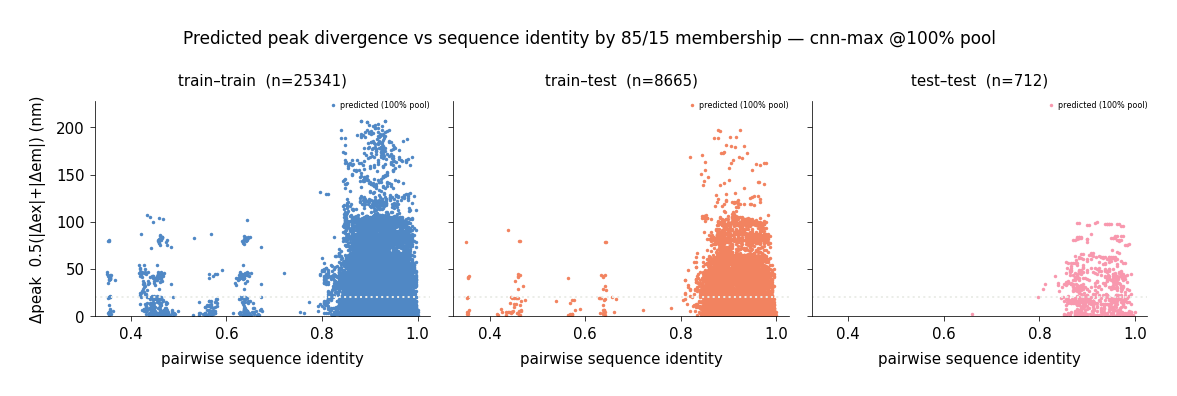

In [23]:
from scipy.stats import spearmanr
# reload the §1 learning-curve model trained on 100% of the 85% pool (cnn-max, seed 0) — top point of the curve
FULL_ARCH="max"; FULL_SEED=0
LC_MODEL=lc_model_path(FULL_ARCH,1.0,FULL_SEED)                   # trained_models/lc_models/cnn-max_p100_s0.pt
PRED100_CACHE=f"trained_models/pred_100pool_cnn-{FULL_ARCH}.npz"  # per-FP peak predictions of that model
def _predict_all(net):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(np.arange(N)): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
if os.path.exists(PRED100_CACHE):
    P100=np.load(PRED100_CACHE)["P"]
    print(f"loaded 100%-pool predictions: {PRED100_CACHE}")
else:
    if not os.path.exists(LC_MODEL):                             # §1 sweep not run yet -> train just this one fit
        sub=np.random.default_rng(FULL_SEED).choice(POOL, len(POOL), replace=False)
        train_eval(FULL_ARCH, sub, TEST, FULL_SEED, save_path=LC_MODEL)
        print(f"§1 checkpoint missing -> trained cnn-{FULL_ARCH} on 100% pool (n_train={len(POOL)})")
    base,ck=pm.load_model(LC_MODEL, dev); net=pm.wrap(base, ck["mean"], ck["std"], dev)
    P100=_predict_all(net); np.savez(PRED100_CACHE, P=P100)
    print(f"reloaded §1 model {LC_MODEL} (n_train={ck.get('n_train')}) and cached predictions: {PRED100_CACHE}")

# identity-aligned pairs (similarity) from §3, predicted vs true peak distance
GT_CACHE="trained_models/similarity_deltapeak_truth.npz"
_gt=np.load(GT_CACHE); Ai,Bi,pid,dpk=_gt["Ai"],_gt["Bi"],_gt["pid"],_gt["dpk"]
dp_pred=0.5*(np.abs(P100[Ai,0]-P100[Bi,0])+np.abs(P100[Ai,1]-P100[Bi,1]))
is_test=np.zeros(N,bool); is_test[TEST]=True
groups={"train–train":(~is_test[Ai])&(~is_test[Bi]),
        "train–test":(is_test[Ai]^is_test[Bi]),
        "test–test":(is_test[Ai])&(is_test[Bi])}
GCOL={"train–train":C("aegean"),"train–test":C("amber"),"test–test":C("rose")}
be=np.linspace(0.6,1.0,9); ct=0.5*(be[:-1]+be[1:]); ymax=float(max(dpk.max(),dp_pred.max()))*1.05
fig,axes=plt.subplots(1,3,figsize=(16,5),sharex=True,sharey=True)
print("group        n_pairs  medΔpred  medΔtrue  med|Δpred-Δtrue|  rho(id,Δpred)")
for ax,(name,m) in zip(axes,groups.items()):
    idx=np.where(m)[0]
    rho=spearmanr(pid[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    err=np.median(np.abs(dp_pred[idx]-dpk[idx])) if len(idx) else np.nan
    print(f"  {name:11} {len(idx):7d}  {np.median(dp_pred[idx]):7.1f}  {np.median(dpk[idx]):7.1f}  {err:14.1f}  {rho:.2f}")
    #ax.scatter(pid[idx],dpk[idx],s=10,alpha=0.12,color=C("gray"),label="ground truth")
    ax.scatter(pid[idx],dp_pred[idx],s=12,alpha=1,color=GCOL[name],label="predicted (100% pool)")
    mdp=[np.median(dp_pred[idx][(pid[idx]>=be[i])&(pid[idx]<be[i+1])]) if ((pid[idx]>=be[i])&(pid[idx]<be[i+1])).any() else np.nan for i in range(8)]
    #ax.plot(ct,mdp,"-o",color=GCOL[name],lw=2)
    ax.axhline(20,ls=":",color=C("gray"))
    ax.set_xlabel("pairwise sequence identity"); ax.set_ylim(0,ymax)
    ax.set_title(f"{name}  (n={len(idx)})"); ax.legend(fontsize=8)
axes[0].set_ylabel("Δpeak  0.5(|Δex|+|Δem|) (nm)")
plt.suptitle(f"Predicted peak divergence vs sequence identity by 85/15 membership — cnn-{FULL_ARCH} @100% pool")
plt.tight_layout(); fig.savefig("trained_models/pairsim_by_split_100pool.png",dpi=130,bbox_inches="tight"); plt.show()

group        n_pairs  med|Δpred-Δtrue|  spearman  pearson    R2
  train–train   25341             3.5     0.97     0.99   0.97
  train–test     8665             5.4     0.88     0.87   0.73
  test–test       712             7.5     0.78     0.74   0.49


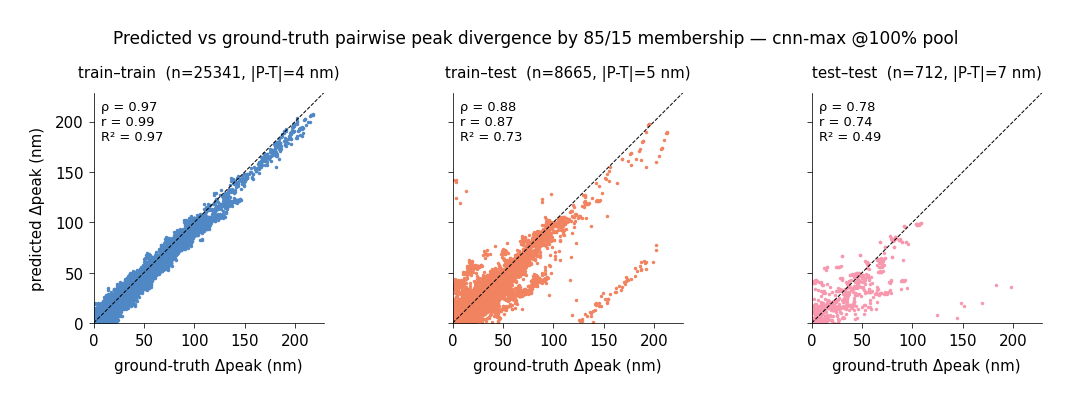

In [19]:
# predicted vs ground-truth pairwise Δpeak (same 100%-pool cnn-max), split by 85/15 membership
from scipy.stats import pearsonr
lim=float(max(dpk.max(),dp_pred.max()))*1.05
fig,axes=plt.subplots(1,3,figsize=(16,5),sharex=True,sharey=True)
print("group        n_pairs  med|Δpred-Δtrue|  spearman  pearson    R2")
for ax,(name,m) in zip(axes,groups.items()):
    idx=np.where(m)[0]
    err=np.median(np.abs(dp_pred[idx]-dpk[idx])) if len(idx) else np.nan
    rho=spearmanr(dpk[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    r=pearsonr(dpk[idx],dp_pred[idx])[0] if len(idx)>2 else np.nan
    r2=1-np.sum((dp_pred[idx]-dpk[idx])**2)/np.sum((dpk[idx]-dpk[idx].mean())**2) if len(idx)>1 else np.nan
    print(f"  {name:11} {len(idx):7d}  {err:14.1f}  {rho:7.2f}  {r:7.2f}  {r2:5.2f}")
    ax.plot([0,lim],[0,lim],ls="--",color=C("black"),lw=1,label="y = x")
    ax.scatter(dpk[idx],dp_pred[idx],s=12,alpha=1,color=GCOL[name])
    ax.text(0.03,0.97,f"ρ = {rho:.2f}\nr = {r:.2f}\nR² = {r2:.2f}",transform=ax.transAxes,va="top",ha="left",fontsize=13)
    ax.set_xlabel("ground-truth Δpeak (nm)"); ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_title(f"{name}  (n={len(idx)}, |P-T|={err:.0f} nm)"); #ax.legend(fontsize=8)
    ax.set_box_aspect(1)
axes[0].set_ylabel("predicted Δpeak (nm)")
plt.suptitle(f"Predicted vs ground-truth pairwise peak divergence by 85/15 membership — cnn-{FULL_ARCH} @100% pool")
plt.tight_layout(); fig.savefig("trained_models/pairdiff_pred_vs_truth_100pool.png",dpi=130,bbox_inches="tight"); plt.show()

test–test: median GT=27.5 nm | median pred=21.0 nm | median(pred−GT)=-4.1 nm | Wilcoxon p=1.67e-24


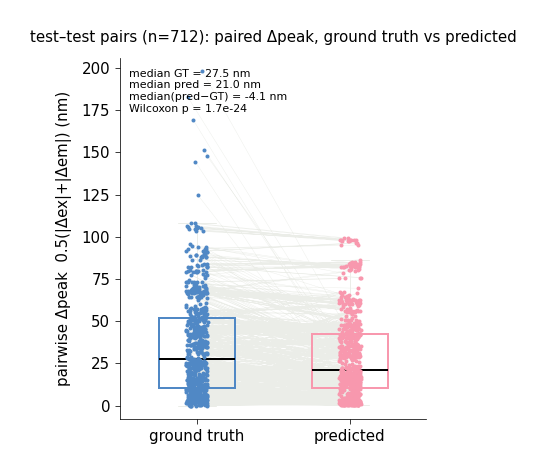

In [26]:
# test–test pairs: paired Δpeak (ground truth vs predicted), same 100%-pool cnn-max
from scipy.stats import wilcoxon
idx=np.where(groups["test–test"])[0]; gt=dpk[idx]; pr=dp_pred[idx]
jit=(np.random.default_rng(0).random(len(idx))-0.5)*0.14
x1=1.0+jit; x2=2.0+jit
fig,ax=plt.subplots(figsize=(5.6,6.2))
segx=np.column_stack([x1,x2,np.full(len(idx),np.nan)]).ravel()      # one artist for all pair-connectors
segy=np.column_stack([gt,pr,np.full(len(idx),np.nan)]).ravel()
ax.plot(segx,segy,color=C("gray"),lw=0.4,alpha=1,zorder=1)
ax.scatter(x1,gt,s=16,alpha=1,color=C("aegean"),zorder=3,label="ground truth")
ax.scatter(x2,pr,s=16,alpha=1,color=C("rose"),zorder=3,label="predicted (100% pool)")
bp=ax.boxplot([gt,pr],positions=[1,2],widths=0.5,showfliers=False,patch_artist=True,zorder=2)
for patch,cc in zip(bp["boxes"],[C("aegean"),C("rose")]): patch.set(facecolor="none",edgecolor=cc,linewidth=2)
for med in bp["medians"]: med.set(color="black",linewidth=2)
for wh in bp["whiskers"]+bp["caps"]: wh.set(color=C("gray"))
ax.set_xticks([1,2]); ax.set_xticklabels(["ground truth","predicted"]); ax.set_xlim(0.5,2.5)
ax.set_ylabel("pairwise Δpeak  0.5(|Δex|+|Δem|) (nm)")
ax.set_title(f"test–test pairs (n={len(idx)}): paired Δpeak, ground truth vs predicted")
W,pval=wilcoxon(pr,gt)
ax.text(0.03,0.97,f"median GT = {np.median(gt):.1f} nm\nmedian pred = {np.median(pr):.1f} nm\nmedian(pred−GT) = {np.median(pr-gt):.1f} nm\nWilcoxon p = {pval:.1e}",
        transform=ax.transAxes,va="top",ha="left",fontsize=11)
print(f"test–test: median GT={np.median(gt):.1f} nm | median pred={np.median(pr):.1f} nm | median(pred−GT)={np.median(pr-gt):.1f} nm | Wilcoxon p={pval:.2e}")
plt.tight_layout(); fig.savefig("trained_models/testtest_paired_deltapeak.png",dpi=130,bbox_inches="tight"); plt.show()

## Notes
- This is a **data** learning curve (test error vs training-set size), distinct from the per-epoch curve.
  Test set is fixed (**15%**, seed 0) so points are comparable; training subsets are drawn from the
  remaining **85%** pool.
- Training-data fractions: **10 / 20 / 50 / 80 / 100%** of the 85% pool. 80 epochs per fit (no val selection).
  Bands are ±1 std over 3 random subset draws per size.
- A still-falling test curve at 100% ⇒ more data would help; a flattening curve + shrinking train↔test gap
  ⇒ data-limited returns. Compare cnn-max vs cnn-concat for which scales better.
- §3 ruggedness is a **data-landscape** diagnostic (model-free): peak divergence vs sequence identity among near-duplicate FP pairs. High-identity median = intrinsic floor; fat upper tail = spectral cliffs that cap a smooth model.
- §1 caches every fit to `trained_models/lc_models/cnn-<pool>_p<frac>_s<seed>.pt`; §4 **reloads** the 100%-pool cnn-max (seed 0) rather than retraining, then predicts peaks for all FPs and plots predicted Δpeak vs sequence identity split by 85/15 membership (train–train / train–test / test–test). Compare panels + the gray ground-truth overlay: tighter tracking on train–train vs test–test exposes how much of the rugged landscape is memorized vs generalized.